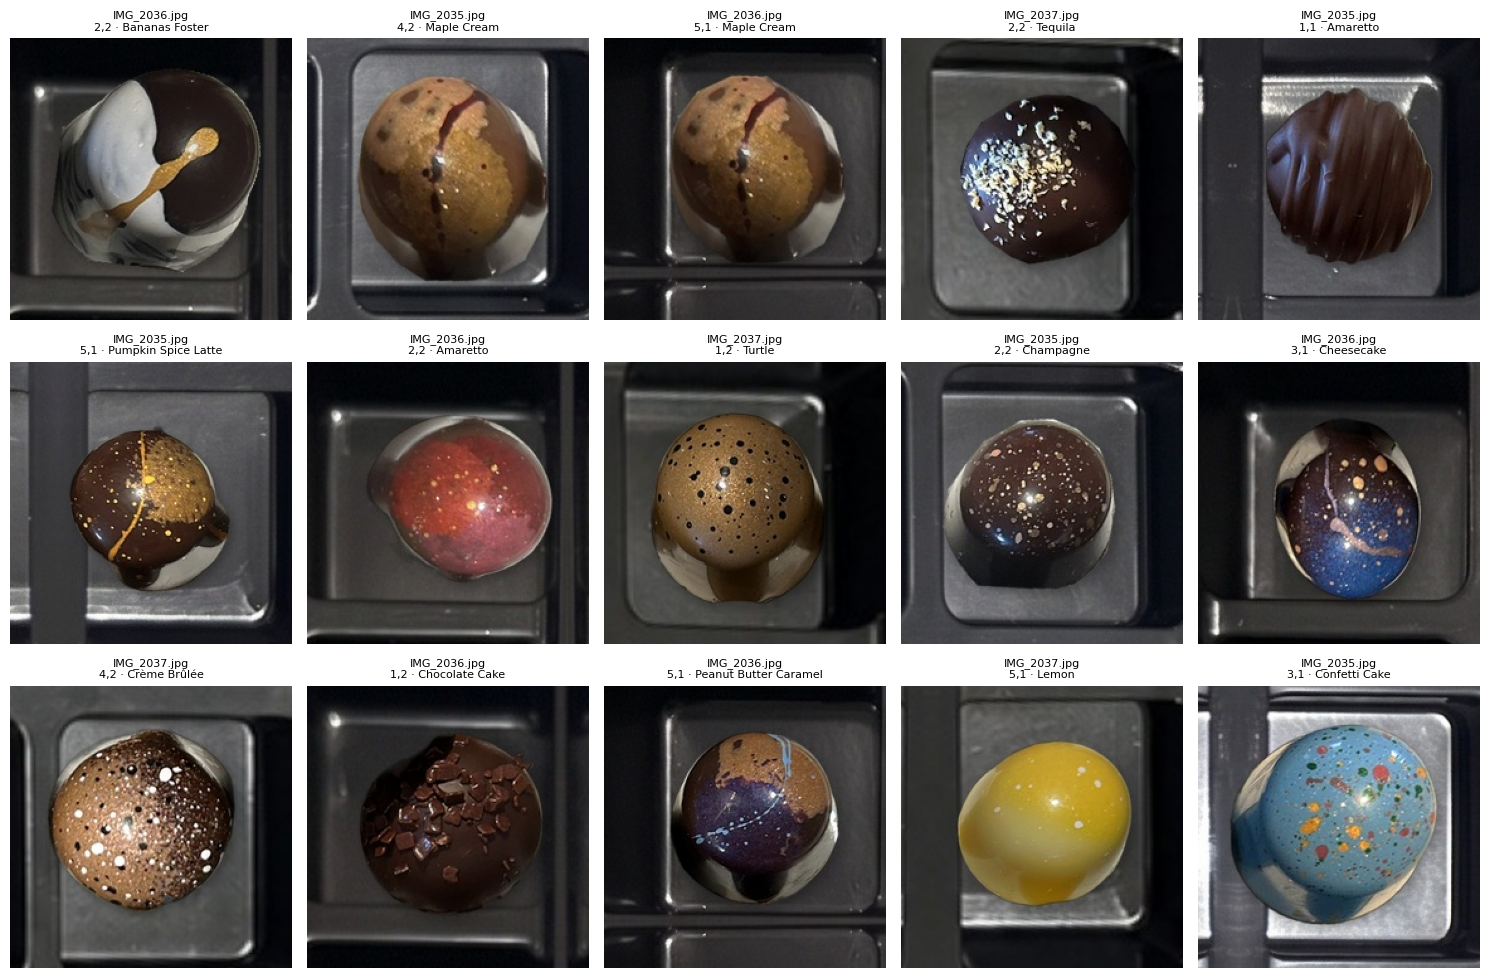

Synthetic occupied slots: 90
Source boxes: 3
Samples per cavity: [3]
Training sources: ['IMG_2035.jpg', 'IMG_2037.jpg']
Validation source: IMG_2036.jpg
Manifest: /homes/mxqasim/Chocolathon/data/synthetic_slots/v2_10_slot/synthetic_slot_manifest.csv
PASS: 90 synthetic occupied 10-slot samples created with the original composition method


In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter

ROOT = Path("/homes/mxqasim/Chocolathon")
EMPTY_MANIFEST = ROOT/"data/boxes/slots/empty_slots_manifest.csv"
DONOR_MANIFEST = ROOT/"data/synthetic_slots/v1/metadata/final_donor_manifest.csv"
OUT_ROOT = ROOT/"data/synthetic_slots/v2_10_slot"
IMAGE_DIR = OUT_ROOT/"images"
MANIFEST_PATH = OUT_ROOT/"synthetic_slot_manifest.csv"
SEED, RENDERS_PER_SLOT = 20260917, 3
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def project_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT/path

PIL_RESAMPLE = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS
PIL_BICUBIC = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC

def augment_donor(foreground, rng):
    foreground = foreground.convert("RGBA")
    bbox = foreground.getchannel("A").getbbox()
    if bbox: foreground = foreground.crop(bbox)
    rgb, alpha = foreground.convert("RGB"), foreground.getchannel("A")
    rgb = ImageEnhance.Brightness(rgb).enhance(rng.uniform(.88, 1.12))
    rgb = ImageEnhance.Contrast(rgb).enhance(rng.uniform(.92, 1.10))
    rgb = ImageEnhance.Color(rgb).enhance(rng.uniform(.92, 1.08))
    foreground = Image.merge("RGBA", (*rgb.split(), alpha))
    foreground = foreground.rotate(rng.uniform(-12, 12), resample=PIL_BICUBIC, expand=True)
    target_side = rng.randint(145, 185)
    scale = target_side/max(foreground.size)
    size = (max(1, round(foreground.width*scale)), max(1, round(foreground.height*scale)))
    return foreground.resize(size, PIL_RESAMPLE)

def compose_synthetic_slot(background_path, foreground_path, rng):
    background = Image.open(background_path).convert("RGBA").resize((224, 224), PIL_RESAMPLE)
    foreground = augment_donor(Image.open(foreground_path), rng)
    x = (224-foreground.width)//2+rng.randint(-9, 9)
    y = (224-foreground.height)//2+rng.randint(-9, 9)
    x = max(-foreground.width//8, min(x, 224-foreground.width+foreground.width//8))
    y = max(-foreground.height//8, min(y, 224-foreground.height+foreground.height//8))
    alpha = foreground.getchannel("A")
    shadow = Image.new("RGBA", (224, 224), (0, 0, 0, 0))
    shadow_patch = Image.new("RGBA", foreground.size, (0, 0, 0, rng.randint(45, 75)))
    shadow_patch.putalpha(alpha.point(lambda value: round(value*.28)))
    shadow.alpha_composite(shadow_patch.filter(ImageFilter.GaussianBlur(rng.uniform(3, 5))), (x+3, y+4))
    result = Image.alpha_composite(background, shadow)
    result.alpha_composite(foreground, (x, y))
    return result.convert("RGB"), {"target_side":max(foreground.size), "offset_x":x, "offset_y":y}

empty = pd.read_csv(EMPTY_MANIFEST)
empty = empty[empty["box_size"].astype(int).eq(10)].sort_values(["source_file","row","column"]).reset_index(drop=True)
donors = pd.read_csv(DONOR_MANIFEST).sort_values("flavor_id").reset_index(drop=True)

assert len(empty) == 30 and empty["source_file"].nunique() == 3
assert len(donors) == 33 and donors["flavor_id"].nunique() == 33
assert empty["slot_path"].map(lambda path: project_path(path).is_file()).all()
assert donors["foreground_path"].map(lambda path: project_path(path).is_file()).all()

sources = sorted(empty["source_file"].unique())
split_rng = random.Random(42)
split_rng.shuffle(sources)
validation_source = sources[0]
split_map = {source:("validation" if source == validation_source else "train") for source in sources}

rng = random.Random(SEED)
records = []

for slot_index, slot in enumerate(empty.itertuples()):
    for render_index in range(RENDERS_PER_SLOT):
        donor = donors.iloc[(slot_index*RENDERS_PER_SLOT+render_index) % len(donors)]
        split = split_map[slot.source_file]
        sample_id = f"{Path(slot.source_file).stem}_r{int(slot.row):02d}_c{int(slot.column):02d}_render{render_index:02d}"
        output_dir = IMAGE_DIR/split/donor["flavor_id"]
        output_dir.mkdir(parents=True, exist_ok=True)
        output_path = output_dir/f"{sample_id}.jpg"

        image, transform = compose_synthetic_slot(project_path(slot.slot_path), project_path(donor["foreground_path"]), rng)
        image.save(output_path, "JPEG", quality=94)

        records.append({
            "sample_id":sample_id, "relative_path":str(output_path.relative_to(ROOT)), "split":split,
            "label_type":"occupied", "flavor_id":donor["flavor_id"], "flavor_name":donor["flavor_name"],
            "donor_sample_id":donor["sample_id"], "donor_source_file":donor["source_file"],
            "extraction_method":donor["extraction_method"], "empty_slot_file":slot.slot_file,
            "empty_source_file":slot.source_file, "box_size":10, "row":int(slot.row),
            "column":int(slot.column), "render_index":render_index, **transform, "seed":SEED
        })

manifest = pd.DataFrame(records)
manifest.to_csv(MANIFEST_PATH, index=False)

assert len(manifest) == 90
assert manifest["sample_id"].nunique() == 90
assert manifest.groupby("empty_slot_file").size().eq(3).all()
assert manifest["relative_path"].map(lambda path: (ROOT/path).is_file()).all()

for path in manifest["relative_path"]:
    with Image.open(ROOT/path) as image:
        assert image.size == (224, 224) and image.mode == "RGB"

sample = manifest.sample(15, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
for axis, row in zip(axes.flat, sample.itertuples()):
    axis.imshow(Image.open(ROOT/row.relative_path))
    axis.set_title(f"{row.empty_source_file}\n{row.row},{row.column} · {row.flavor_name}", fontsize=8)
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Synthetic occupied slots:", len(manifest))
print("Source boxes:", manifest["empty_source_file"].nunique())
print("Samples per cavity:", manifest.groupby("empty_slot_file").size().unique().tolist())
print("Training sources:", sorted(source for source, split in split_map.items() if split == "train"))
print("Validation source:", validation_source)
print("Manifest:", MANIFEST_PATH)
print("PASS: 90 synthetic occupied 10-slot samples created with the original composition method")

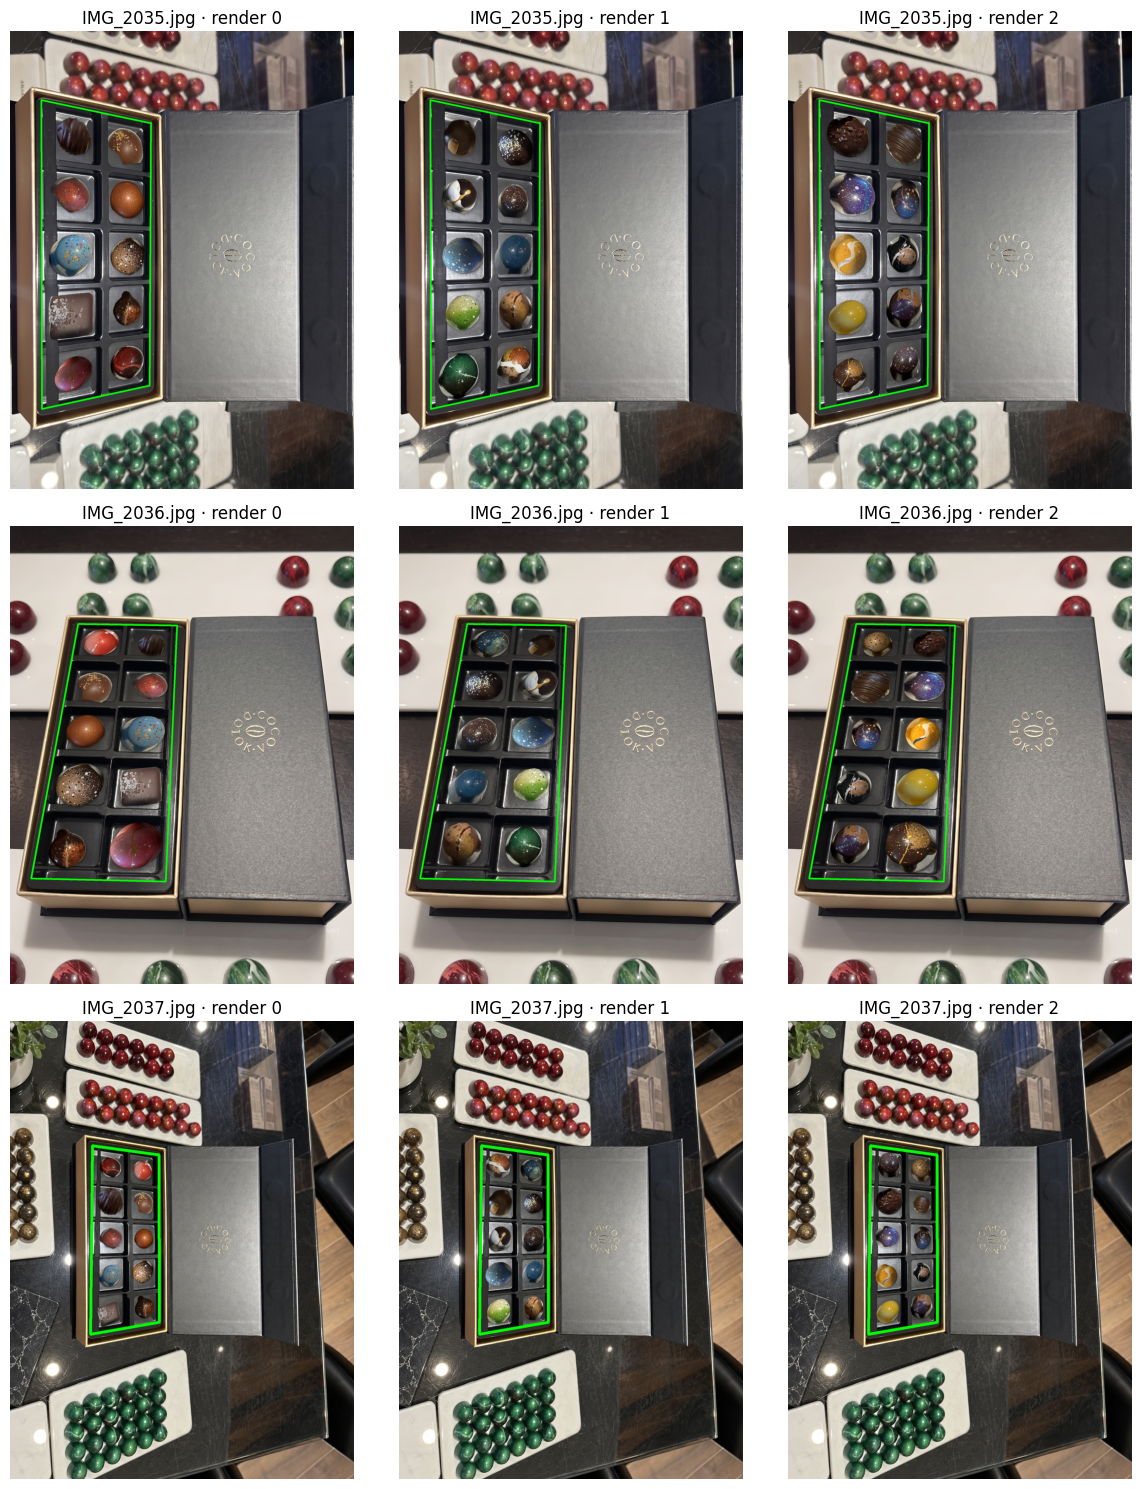

Generated filled boxes: 9
Source boxes: 3
Renders per source: [3]
Total occupied slots: 90
Manifest: /homes/mxqasim/Chocolathon/data/synthetic_filled_boxes/v5_10_slot/manifest.csv
PASS: nine completely filled 10-slot boxes generated with the original v4 rendering method


In [2]:
from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

ROOT = Path("/homes/mxqasim/Chocolathon")
BOX_MANIFEST = ROOT/"data/boxes/manifest.csv"
EMPTY_MANIFEST = ROOT/"data/boxes/slots/empty_slots_manifest.csv"
SLOT_MANIFEST = ROOT/"data/synthetic_slots/v2_10_slot/synthetic_slot_manifest.csv"
RAW_DIR = ROOT/"data/boxes/raw"
OUT_ROOT = ROOT/"data/synthetic_filled_boxes/v5_10_slot"
IMAGE_DIR, GT_DIR = OUT_ROOT/"images", OUT_ROOT/"ground_truth"
MANIFEST_PATH = OUT_ROOT/"manifest.csv"
CORNER_NAMES, ROWS, COLUMNS, CELL = ("top_left","top_right","bottom_right","bottom_left"), 5, 2, 256
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
GT_DIR.mkdir(parents=True, exist_ok=True)

def project_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT/path

def load_rgb(path):
    with Image.open(project_path(path)) as image:
        return np.asarray(ImageOps.exif_transpose(image).convert("RGB"))

def load_box(box):
    raw = load_rgb(RAW_DIR/box.file)
    annotation = json.loads(project_path(box.annotation_file).read_text())
    height, width = raw.shape[:2]
    assert (width, height) == (int(annotation["image_width"]), int(annotation["image_height"]))
    corners = np.asarray([annotation["corners"][name] for name in CORNER_NAMES], np.float32)
    assert corners.shape == (4, 2) and np.isfinite(corners).all() and cv2.isContourConvex(corners)
    return raw, corners

def stitch_slots(samples, positions):
    tray = np.full((ROWS*CELL, COLUMNS*CELL, 3), 28, np.uint8)
    ground_truth = []

    for sample in samples.itertuples():
        row, column = positions[sample.empty_slot_file]
        slot = load_rgb(sample.relative_path)
        interpolation = cv2.INTER_AREA if max(slot.shape[:2]) > CELL else cv2.INTER_CUBIC
        slot = cv2.resize(slot, (CELL, CELL), interpolation=interpolation)
        y1, x1 = (row-1)*CELL, (column-1)*CELL
        tray[y1:y1+CELL, x1:x1+CELL] = slot

        ground_truth.append({
            "row":row, "column":column, "slot_file":sample.empty_slot_file,
            "sample_id":sample.sample_id, "flavor_id":sample.flavor_id,
            "flavor_name":sample.flavor_name, "label_type":"occupied",
            "image_path":str(project_path(sample.relative_path))
        })

    assert len(ground_truth) == 10
    assert len({(item["row"], item["column"]) for item in ground_truth}) == 10
    return tray, ground_truth

def warp_tray(raw, tray, corners):
    tray_height, tray_width = tray.shape[:2]
    raw_height, raw_width = raw.shape[:2]
    source = np.float32([[0,0],[tray_width-1,0],[tray_width-1,tray_height-1],[0,tray_height-1]])
    matrix = cv2.getPerspectiveTransform(source, corners)
    warped = cv2.warpPerspective(tray, matrix, (raw_width,raw_height), flags=cv2.INTER_LINEAR)
    mask = cv2.warpPerspective(np.full((tray_height,tray_width),255,np.uint8), matrix, (raw_width,raw_height), flags=cv2.INTER_NEAREST)
    mask = cv2.erode(mask, np.ones((5,5),np.uint8), iterations=1)
    alpha = (cv2.GaussianBlur(mask,(11,11),0).astype(np.float32)/255)[...,None]
    return np.clip(raw.astype(np.float32)*(1-alpha)+warped.astype(np.float32)*alpha,0,255).astype(np.uint8)

boxes = pd.read_csv(BOX_MANIFEST)
boxes = boxes[boxes["box_size"].astype(int).eq(10)].sort_values("file").reset_index(drop=True)
empty = pd.read_csv(EMPTY_MANIFEST)
empty = empty[empty["box_size"].astype(int).eq(10)].copy()
slots = pd.read_csv(SLOT_MANIFEST)

assert len(boxes) == 3 and len(empty) == 30 and len(slots) == 90
assert set(boxes["file"]) == {"IMG_2035.jpg","IMG_2036.jpg","IMG_2037.jpg"}
positions = {row.slot_file:(int(row.row),int(row.column)) for row in empty.itertuples()}
records = []

for box in boxes.itertuples():
    source_slots = slots[slots["empty_source_file"].eq(box.file)]
    assert len(source_slots) == 30

    raw, corners = load_box(box)

    for render_index in range(3):
        selected = source_slots[source_slots["render_index"].astype(int).eq(render_index)].copy()
        assert len(selected) == 10 and selected["empty_slot_file"].nunique() == 10

        tray, truth = stitch_slots(selected, positions)
        filled = warp_tray(raw, tray, corners)
        name = f"{Path(box.file).stem}_size10_render{render_index:02d}"
        image_path, gt_path = IMAGE_DIR/f"{name}.jpg", GT_DIR/f"{name}.csv"

        Image.fromarray(filled).save(image_path, "JPEG", quality=95, subsampling=0)
        gt = pd.DataFrame(truth)
        gt.insert(0, "image", str(image_path))
        gt.insert(1, "source_file", box.file)
        gt.insert(2, "box_size", 10)
        gt.insert(3, "render_index", render_index)
        gt.to_csv(gt_path, index=False)

        records.append({
            "image":str(image_path), "gt_path":str(gt_path), "source_file":box.file,
            "box_size":10, "render_index":render_index, "slots":10,
            "occupied":10, "empty":0, "corners":json.dumps(corners.tolist())
        })

manifest = pd.DataFrame(records)
manifest.to_csv(MANIFEST_PATH, index=False)

assert len(manifest) == 9
assert manifest.groupby("source_file").size().eq(3).all()
assert manifest["image"].map(lambda path: Path(path).is_file()).all()
assert manifest["gt_path"].map(lambda path: Path(path).is_file()).all()

for item in manifest.itertuples():
    generated = load_rgb(item.image)
    source = load_rgb(RAW_DIR/item.source_file)
    truth = pd.read_csv(item.gt_path)
    assert generated.shape == source.shape
    assert len(truth) == 10 and not truth.duplicated(["row","column"]).any()
    assert set(zip(truth["row"],truth["column"])) == {(row,column) for row in range(1,6) for column in range(1,3)}

fig, axes = plt.subplots(3,3,figsize=(12,15))
for axis, item in zip(axes.flat, manifest.itertuples()):
    preview = load_rgb(item.image).copy()
    cv2.polylines(preview,[np.asarray(json.loads(item.corners),np.int32)],True,(0,255,0),8)
    axis.imshow(preview)
    axis.set_title(f"{item.source_file} · render {item.render_index}")
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Generated filled boxes:", len(manifest))
print("Source boxes:", manifest["source_file"].nunique())
print("Renders per source:", manifest.groupby("source_file").size().unique().tolist())
print("Total occupied slots:", int(manifest["occupied"].sum()))
print("Manifest:", MANIFEST_PATH)
print("PASS: nine completely filled 10-slot boxes generated with the original v4 rendering method")

In [3]:
from pathlib import Path
import copy, json, random, time
import cv2
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0

SEED, IMAGE_SIZE, BATCH_SIZE = 42, 224, 8
MAX_EPOCHS, PATIENCE = 20, 5
BACKBONE_LR, HEAD_LR, WEIGHT_DECAY = 1e-5, 2e-4, 1e-4
ROOT = Path("/homes/mxqasim/Chocolathon")
BOX_ROOT = ROOT/"data/boxes"
V4_MANIFEST = ROOT/"data/synthetic_filled_boxes/v4/manifest.csv"
V5_MANIFEST = ROOT/"data/synthetic_filled_boxes/v5_10_slot/manifest.csv"
CURRENT_MODEL = ROOT/"data/experiments/box_localization_v3/deployment/efficientnet_b0_box_size_classifier.pt"
RUN_DIR = ROOT/"data/experiments/box_localization_v4"
CANDIDATE = RUN_DIR/"efficientnet_b0_box_size_classifier_5class_candidate.pt"
CAPACITIES, OLD_CAPACITIES = [6,10,16,30,50], [6,16,30,50]
CAPACITY_TO_INDEX = {capacity:index for index,capacity in enumerate(CAPACITIES)}
VALIDATION_SOURCES = {6:"IMG_2021.jpg",10:"IMG_2036.jpg",16:"IMG_2026.jpg",30:"IMG_2030.jpg",50:"IMG_2034.jpg"}
CORNER_NAMES = ("top_left","top_right","bottom_right","bottom_left")
MEAN = np.array([.485,.456,.406],np.float32)
STD = np.array([.229,.224,.225],np.float32)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_DIR.mkdir(parents=True,exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(4)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def project_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT/path

records = []
boxes = pd.read_csv(BOX_ROOT/"manifest.csv")
for box in boxes.itertuples():
    annotation = json.loads(project_path(box.annotation_file).read_text())
    corners = [annotation["corners"][name] for name in CORNER_NAMES]
    records.append({"image":str((BOX_ROOT/"raw"/box.file).resolve()),"source_file":box.file,
                    "box_size":int(box.box_size),"kind":"original_empty","corners":json.dumps(corners)})

for manifest_path,kind in [(V4_MANIFEST,"synthetic_v4"),(V5_MANIFEST,"synthetic_v5_10")]:
    for item in pd.read_csv(manifest_path).itertuples():
        records.append({"image":str(project_path(item.image)),"source_file":item.source_file,
                        "box_size":int(item.box_size),"kind":kind,"corners":item.corners})

dataset = pd.DataFrame(records)
dataset["class_index"] = dataset["box_size"].map(CAPACITY_TO_INDEX)
dataset["split"] = dataset.apply(
    lambda row:"validation" if row["source_file"] == VALIDATION_SOURCES[int(row["box_size"])] else "train",axis=1
)

assert len(dataset) == 76 and dataset["image"].map(lambda path:Path(path).is_file()).all()
assert dataset.groupby("source_file").size().eq(4).all()
assert set(dataset.box_size) == set(CAPACITIES)
assert set(dataset.loc[dataset.split.eq("train"),"source_file"]).isdisjoint(
    set(dataset.loc[dataset.split.eq("validation"),"source_file"])
)
assert dataset.groupby(["split","box_size"]).size().to_dict() == {
    ("train",6):8,("train",10):8,("train",16):16,("train",30):12,("train",50):12,
    ("validation",6):4,("validation",10):4,("validation",16):4,("validation",30):4,("validation",50):4
}
dataset.to_csv(RUN_DIR/"capacity_dataset.csv",index=False)

class CapacityDataset(Dataset):
    def __init__(self,frame,augment=False):
        self.frame,self.augment = frame.reset_index(drop=True),augment

    def __len__(self): return len(self.frame)

    def __getitem__(self,index):
        row = self.frame.iloc[index]
        bgr = cv2.imread(row.image)
        if bgr is None: raise ValueError(f"Cannot decode {row.image}")
        image = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        height,width = image.shape[:2]
        corners = np.asarray(json.loads(row.corners),np.float32).reshape(4,2)
        corners *= np.array([IMAGE_SIZE/width,IMAGE_SIZE/height],np.float32)
        image = cv2.resize(image,(IMAGE_SIZE,IMAGE_SIZE),interpolation=cv2.INTER_AREA)

        if self.augment:
            image = np.clip(image.astype(np.float32)*np.random.uniform(.85,1.15)+np.random.uniform(-18,18),0,255).astype(np.uint8)
            if np.random.rand() < .25: image = cv2.GaussianBlur(image,(3,3),0)
            if np.random.rand() < .25:
                image = np.clip(image.astype(np.float32)+np.random.normal(0,3,image.shape),0,255).astype(np.uint8)

            matrix = cv2.getRotationMatrix2D(((IMAGE_SIZE-1)/2,(IMAGE_SIZE-1)/2),np.random.uniform(-3,3),np.random.uniform(.96,1.04))
            matrix[:,2] += [np.random.uniform(-6,6),np.random.uniform(-6,6)]
            transformed = cv2.transform(corners[None],matrix)[0]
            if np.all((transformed >= 0) & (transformed < IMAGE_SIZE)):
                image = cv2.warpAffine(image,matrix,(IMAGE_SIZE,IMAGE_SIZE),flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_REFLECT_101)

        tensor = torch.from_numpy((((image.astype(np.float32)/255)-MEAN)/STD).transpose(2,0,1)).float()
        return tensor,torch.tensor(int(row.class_index),dtype=torch.long),row.source_file,row.kind

class BoxSizeClassifier(nn.Module):
    def __init__(self,num_classes=5):
        super().__init__()
        self.features = efficientnet_b0(weights=None).features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(),nn.Linear(1280,128),nn.SiLU(),nn.Dropout(.2),nn.Linear(128,num_classes))

    def forward(self,inputs): return self.classifier(self.pool(self.features(inputs)))

train_data = CapacityDataset(dataset[dataset.split.eq("train")],augment=True)
validation_data = CapacityDataset(dataset[dataset.split.eq("validation")])
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,generator=generator)
validation_loader = DataLoader(validation_data,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

model = BoxSizeClassifier(5)
old_state = torch.load(CURRENT_MODEL,map_location="cpu",weights_only=True)
new_state = model.state_dict()

for key,value in old_state.items():
    if key in new_state and new_state[key].shape == value.shape: new_state[key] = value.clone()

for old_index,capacity in enumerate(OLD_CAPACITIES):
    new_index = CAPACITY_TO_INDEX[capacity]
    new_state["classifier.4.weight"][new_index] = old_state["classifier.4.weight"][old_index]
    new_state["classifier.4.bias"][new_index] = old_state["classifier.4.bias"][old_index]

new_state["classifier.4.weight"][CAPACITY_TO_INDEX[10]] = (
    old_state["classifier.4.weight"][OLD_CAPACITIES.index(6)] +
    old_state["classifier.4.weight"][OLD_CAPACITIES.index(16)]
)/2
new_state["classifier.4.bias"][CAPACITY_TO_INDEX[10]] = (
    old_state["classifier.4.bias"][OLD_CAPACITIES.index(6)] +
    old_state["classifier.4.bias"][OLD_CAPACITIES.index(16)]
)/2
model.load_state_dict(new_state,strict=True)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW([
    {"params":model.features.parameters(),"lr":BACKBONE_LR},
    {"params":model.classifier.parameters(),"lr":HEAD_LR}
],weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=.5,patience=2)

@torch.inference_mode()
def evaluate(model):
    model.eval()
    rows,loss_total,total = [],0.0,0
    for images,targets,sources,kinds in validation_loader:
        images,targets = images.to(DEVICE),targets.to(DEVICE)
        logits = model(images)
        probabilities = logits.softmax(1)
        loss_total += F.cross_entropy(logits,targets,label_smoothing=.05).item()*len(images)
        predictions = probabilities.argmax(1)
        for i in range(len(images)):
            rows.append({
                "source_file":sources[i],"kind":kinds[i],
                "expected_capacity":CAPACITIES[int(targets[i])],
                "predicted_capacity":CAPACITIES[int(predictions[i])],
                "confidence":float(probabilities[i].max()),"correct":bool(predictions[i] == targets[i])
            })
        total += len(images)
    results = pd.DataFrame(rows)
    return loss_total/total,float(results.correct.mean()),results

best_state,best_accuracy,best_loss = copy.deepcopy(model.state_dict()),-1.0,float("inf")
history,patience_left = [],PATIENCE

print("Device:",DEVICE)
print("Training images:",len(train_data),"| Validation images:",len(validation_data))
print("Training five-class capacity classifier...")

for epoch in range(1,MAX_EPOCHS+1):
    started = time.perf_counter()
    model.train()
    running_loss,correct,total = 0.0,0,0

    for images,targets,_,_ in train_loader:
        images,targets = images.to(DEVICE),targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = F.cross_entropy(logits,targets,label_smoothing=.05)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        running_loss += loss.item()*len(images)
        correct += (logits.argmax(1) == targets).sum().item()
        total += len(images)

    validation_loss,validation_accuracy,_ = evaluate(model)
    scheduler.step(validation_accuracy)
    train_loss,train_accuracy = running_loss/total,correct/total
    improved = validation_accuracy > best_accuracy or (validation_accuracy == best_accuracy and validation_loss < best_loss)

    if improved:
        best_state,best_accuracy,best_loss = copy.deepcopy(model.state_dict()),validation_accuracy,validation_loss
        patience_left = PATIENCE
    else: patience_left -= 1

    history.append({"epoch":epoch,"train_loss":train_loss,"train_accuracy":train_accuracy,
                    "validation_loss":validation_loss,"validation_accuracy":validation_accuracy,
                    "seconds":time.perf_counter()-started})

    print(f"EPOCH {epoch:02d} | train={train_loss:.4f}/{train_accuracy:.3f} | "
          f"validation={validation_loss:.4f}/{validation_accuracy:.3f} | "
          f"{history[-1]['seconds']:.1f}s")

    if patience_left == 0:
        print("Early stopping")
        break

model.load_state_dict(best_state)
final_loss,final_accuracy,predictions = evaluate(model)
torch.save(model.state_dict(),CANDIDATE)
pd.DataFrame(history).to_csv(RUN_DIR/"capacity_training_history.csv",index=False)
predictions.to_csv(RUN_DIR/"capacity_validation_predictions.csv",index=False)

print("\nValidation predictions:")
print(predictions.to_string(index=False))
print("\nConfusion matrix:")
print(pd.crosstab(predictions.expected_capacity,predictions.predicted_capacity))
print("\nBest validation accuracy:",final_accuracy)
print("Candidate:",CANDIDATE)
print("PASS: five-class candidate trained" if final_accuracy == 1.0 else "REVIEW: candidate did not reach 100% held-out accuracy")

/homes/mxqasim/Chocolathon/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Device: cpu
Training images: 56 | Validation images: 20
Training five-class capacity classifier...
EPOCH 01 | train=0.4986/0.857 | validation=0.7347/0.800 | 17.4s
EPOCH 02 | train=0.5261/0.857 | validation=0.7062/0.800 | 9.8s
EPOCH 03 | train=0.5850/0.821 | validation=0.7030/0.800 | 9.4s
EPOCH 04 | train=0.5039/0.857 | validation=0.6686/0.800 | 9.4s
EPOCH 05 | train=0.4647/0.857 | validation=0.6747/0.800 | 9.3s
EPOCH 06 | train=0.4927/0.839 | validation=0.6541/0.800 | 9.4s
EPOCH 07 | train=0.4911/0.857 | validation=0.6656/0.800 | 9.5s
EPOCH 08 | train=0.4883/0.857 | validation=0.6527/0.800 | 9.6s
EPOCH 09 | train=0.4428/0.857 | validation=0.6498/0.800 | 9.5s
EPOCH 10 | train=0.4434/0.875 | validation=0.6919/0.800 | 9.5s
EPOCH 11 | train=0.4729/0.875 | validation=0.6515/0.800 | 9.4s
EPOCH 12 | train=0.4330/0.875 | validation=0.6570/0.800 | 9.4s
EPOCH 13 | train=0.4458/0.839 | validation=0.6632/0.800 | 9.4s
EPOCH 14 | train=0.4707/0.857 | validation=0.6738/0.800 | 9.3s
Early stopping

Va

In [4]:
from torch.utils.data import WeightedRandomSampler

BALANCED_CANDIDATE = RUN_DIR/"efficientnet_b0_box_size_classifier_5class_balanced_candidate.pt"
BALANCED_HISTORY = RUN_DIR/"capacity_balanced_training_history.csv"
BALANCED_PREDICTIONS = RUN_DIR/"capacity_balanced_validation_predictions.csv"

def initialize_five_class_model():
    model = BoxSizeClassifier(5)
    old = torch.load(CURRENT_MODEL,map_location="cpu",weights_only=True)
    state = model.state_dict()

    for key,value in old.items():
        if key in state and state[key].shape == value.shape: state[key] = value.clone()

    for old_index,capacity in enumerate(OLD_CAPACITIES):
        new_index = CAPACITY_TO_INDEX[capacity]
        state["classifier.4.weight"][new_index] = old["classifier.4.weight"][old_index]
        state["classifier.4.bias"][new_index] = old["classifier.4.bias"][old_index]

    ten_index = CAPACITY_TO_INDEX[10]
    state["classifier.4.weight"][ten_index] = (
        old["classifier.4.weight"][OLD_CAPACITIES.index(6)] +
        old["classifier.4.weight"][OLD_CAPACITIES.index(16)]
    )/2
    state["classifier.4.bias"][ten_index] = (
        old["classifier.4.bias"][OLD_CAPACITIES.index(6)] +
        old["classifier.4.bias"][OLD_CAPACITIES.index(16)]
    )/2
    model.load_state_dict(state,strict=True)
    return model.to(DEVICE)

train_data = CapacityDataset(dataset[dataset.split.eq("train")],augment=True)
validation_data = CapacityDataset(dataset[dataset.split.eq("validation")])
class_counts = train_data.frame["class_index"].value_counts().to_dict()
sample_weights = train_data.frame["class_index"].map(lambda index:1/class_counts[index]).to_numpy()
sampler = WeightedRandomSampler(
    torch.as_tensor(sample_weights,dtype=torch.double),
    num_samples=100,replacement=True,
    generator=torch.Generator().manual_seed(SEED)
)
balanced_loader = DataLoader(train_data,batch_size=BATCH_SIZE,sampler=sampler,num_workers=0)
validation_loader = DataLoader(validation_data,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

model = initialize_five_class_model()
history = []
best_state = copy.deepcopy(model.state_dict())
best_accuracy,best_loss = -1.0,float("inf")

def train_phase(name,epochs,optimizer,patience=6):
    global best_state,best_accuracy,best_loss
    patience_left = patience

    for epoch in range(1,epochs+1):
        started = time.perf_counter()
        model.train()
        running_loss,correct,total = 0.0,0,0

        for images,targets,_,_ in balanced_loader:
            images,targets = images.to(DEVICE),targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = F.cross_entropy(logits,targets,label_smoothing=.02)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            running_loss += loss.item()*len(images)
            correct += (logits.argmax(1) == targets).sum().item()
            total += len(images)

        validation_loss,validation_accuracy,_ = evaluate(model)
        train_loss,train_accuracy = running_loss/total,correct/total
        improved = validation_accuracy > best_accuracy or (
            validation_accuracy == best_accuracy and validation_loss < best_loss
        )

        if improved:
            best_state = copy.deepcopy(model.state_dict())
            best_accuracy,best_loss = validation_accuracy,validation_loss
            patience_left = patience
        else:
            patience_left -= 1

        row = {
            "phase":name,"epoch":epoch,"train_loss":train_loss,
            "train_accuracy":train_accuracy,"validation_loss":validation_loss,
            "validation_accuracy":validation_accuracy,"seconds":time.perf_counter()-started
        }
        history.append(row)
        print(f"{name} {epoch:02d} | train={train_loss:.4f}/{train_accuracy:.3f} | "
              f"validation={validation_loss:.4f}/{validation_accuracy:.3f} | {row['seconds']:.1f}s")

        if patience_left == 0:
            print(f"{name}: early stopping")
            break

# Phase 1: teach the classifier head the new class without changing the backbone.
for parameter in model.features.parameters(): parameter.requires_grad = False
for parameter in model.classifier.parameters(): parameter.requires_grad = True
head_optimizer = torch.optim.AdamW(model.classifier.parameters(),lr=1e-3,weight_decay=1e-4)
print("PHASE 1 — balanced classifier-head warm-up")
train_phase("head",12,head_optimizer)

model.load_state_dict(best_state)

# Phase 2: adapt only the last two EfficientNet blocks and classifier.
for parameter in model.features.parameters(): parameter.requires_grad = False
for block in list(model.features.children())[-2:]:
    for parameter in block.parameters(): parameter.requires_grad = True

feature_parameters = [parameter for parameter in model.features.parameters() if parameter.requires_grad]
fine_optimizer = torch.optim.AdamW([
    {"params":feature_parameters,"lr":1e-5},
    {"params":model.classifier.parameters(),"lr":2e-4}
],weight_decay=1e-4)

print("\nPHASE 2 — limited balanced fine-tuning")
train_phase("fine",20,fine_optimizer)

model.load_state_dict(best_state)
final_loss,final_accuracy,predictions = evaluate(model)
torch.save(model.state_dict(),BALANCED_CANDIDATE)
pd.DataFrame(history).to_csv(BALANCED_HISTORY,index=False)
predictions.to_csv(BALANCED_PREDICTIONS,index=False)

per_capacity = predictions.groupby("expected_capacity").agg(
    images=("correct","size"),
    correct=("correct","sum"),
    accuracy=("correct","mean"),
    mean_confidence=("confidence","mean")
)

print("\nValidation predictions:")
print(predictions.to_string(index=False))
print("\nPer-capacity validation:")
print(per_capacity.to_string())
print("\nConfusion matrix:")
print(pd.crosstab(predictions.expected_capacity,predictions.predicted_capacity))
print("\nBest validation accuracy:",final_accuracy)
print("Candidate:",BALANCED_CANDIDATE)
print("PASS: balanced five-class candidate reached 100% held-out accuracy"
      if final_accuracy == 1.0 else
      "REVIEW: five-class candidate still needs adjustment; deployment was not changed")

PHASE 1 — balanced classifier-head warm-up
head 01 | train=0.6299/0.770 | validation=0.8301/0.750 | 8.5s
head 02 | train=0.4353/0.830 | validation=0.7472/0.800 | 8.6s
head 03 | train=0.4262/0.860 | validation=0.6119/0.800 | 8.4s
head 04 | train=0.3185/0.940 | validation=0.6328/0.800 | 8.7s
head 05 | train=0.2362/0.990 | validation=0.5720/0.800 | 8.6s
head 06 | train=0.2942/0.940 | validation=0.4488/0.950 | 8.0s
head 07 | train=0.2913/0.930 | validation=0.4832/0.900 | 8.5s
head 08 | train=0.2480/0.990 | validation=0.5639/0.850 | 8.4s
head 09 | train=0.1681/1.000 | validation=0.4078/0.950 | 8.0s
head 10 | train=0.2013/0.980 | validation=0.4807/0.850 | 8.5s
head 11 | train=0.2818/0.960 | validation=0.4187/0.950 | 8.4s
head 12 | train=0.1710/1.000 | validation=0.3867/0.950 | 7.9s

PHASE 2 — limited balanced fine-tuning
fine 01 | train=0.1536/0.990 | validation=0.4090/0.900 | 8.5s
fine 02 | train=0.1700/1.000 | validation=0.4257/0.950 | 8.6s
fine 03 | train=0.1600/0.990 | validation=0.4849/

In [5]:
import torch, pandas as pd
from torch.utils.data import DataLoader

candidate_path = RUN_DIR / "efficientnet_b0_box_size_classifier_5class_balanced_candidate.pt"
candidate_model = initialize_five_class_model().to(DEVICE)
candidate_model.load_state_dict(torch.load(candidate_path, map_location=DEVICE))
candidate_model.eval()

record_pool = None
for name, value in globals().items():
    if isinstance(value, (list, tuple)) and value and isinstance(value[0], dict) and {"source_file", "expected_capacity"}.issubset(value[0]):
        if record_pool is None or len(value) > len(record_pool): record_pool = list(value)
assert record_pool is not None, "Could not find the combined dataset records."

eval_transform = globals().get("validation_transform", globals().get("val_transform", globals().get("eval_transform")))
assert eval_transform is not None, "Could not find the validation transform."

original_records = [r for r in record_pool if r.get("kind") == "original_empty"]
ten_records = [r for r in original_records if int(r["expected_capacity"]) == 10]
check_records = original_records

check_dataset = CapacityDataset(check_records, eval_transform)
check_loader = DataLoader(check_dataset, batch_size=8, shuffle=False, num_workers=0)

rows = []
with torch.no_grad():
    for images, labels in check_loader:
        probabilities = candidate_model(images.to(DEVICE)).softmax(1).cpu()
        predictions = probabilities.argmax(1)
        for expected, predicted, confidence in zip(labels.tolist(), predictions.tolist(), probabilities.max(1).values.tolist()):
            rows.append({"expected": CAPACITIES[expected], "predicted": CAPACITIES[predicted], "confidence": confidence, "correct": expected == predicted})

result = pd.DataFrame(rows)
print(result.to_string(index=False))
print("\nAccuracy:", result.correct.mean())
print("\nConfusion matrix:")
print(pd.crosstab(result.expected, result.predicted))

ten_result = result[result.expected == 10]
print("\n10-slot originals:")
print(ten_result.to_string(index=False))

AssertionError: Could not find the combined dataset records.

In [12]:
import torch, pandas as pd
from torch.utils.data import DataLoader

candidate_model = initialize_five_class_model()
candidate_model.load_state_dict(torch.load(BALANCED_CANDIDATE,map_location=DEVICE,weights_only=True))
candidate_model.eval()

original_frame = dataset[dataset.kind.eq("original_empty")].copy()
original_data = CapacityDataset(original_frame)
original_loader = DataLoader(original_data,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

rows = []
with torch.no_grad():
    for images,targets,source_files,kinds in original_loader:
        probabilities = candidate_model(images.to(DEVICE)).softmax(1).cpu()
        predictions = probabilities.argmax(1)
        confidences = probabilities.max(1).values

        for source,target,prediction,confidence in zip(source_files,targets.tolist(),predictions.tolist(),confidences.tolist()):
            rows.append({
                "source_file":source,
                "expected_capacity":CAPACITIES[target],
                "predicted_capacity":CAPACITIES[prediction],
                "confidence":confidence,
                "correct":target == prediction
            })

original_predictions = pd.DataFrame(rows)
print(original_predictions.to_string(index=False))

print(f"\nOriginal images: {len(original_predictions)}")
print(f"Original-box accuracy: {original_predictions.correct.mean():.3f}")

print("\nPer-capacity original-box accuracy:")
print(original_predictions.groupby("expected_capacity").agg(
    images=("correct","size"),
    correct=("correct","sum"),
    accuracy=("correct","mean"),
    mean_confidence=("confidence","mean")
).to_string())

print("\nConfusion matrix:")
print(pd.crosstab(
    original_predictions.expected_capacity,
    original_predictions.predicted_capacity
))

print("\n10-slot originals:")
print(original_predictions[
    original_predictions.expected_capacity.eq(10)
].to_string(index=False))

 source_file  expected_capacity  predicted_capacity  confidence  correct
IMG_2019.jpg                  6                   6    0.999752     True
IMG_2020.jpg                  6                   6    0.999954     True
IMG_2021.jpg                  6                   6    0.999671     True
IMG_2022.jpg                 16                  16    0.984269     True
IMG_2023.jpg                 16                  16    0.994482     True
IMG_2024.jpg                 16                  16    0.999042     True
IMG_2025.jpg                 16                  16    0.998866     True
IMG_2026.jpg                 16                  16    0.937260     True
IMG_2027.jpg                 30                  30    0.932237     True
IMG_2028.jpg                 30                  30    0.985431     True
IMG_2029.jpg                 30                  30    0.992506     True
IMG_2030.jpg                 30                  30    0.790569     True
IMG_2031.jpg                 50                  50

In [14]:
import torch, pandas as pd
from torch.utils.data import DataLoader

old_model = BoxSizeClassifier(4).to(DEVICE)
old_model.load_state_dict(torch.load(CURRENT_MODEL,map_location=DEVICE,weights_only=True))
old_model.eval()

new_model = initialize_five_class_model()
new_model.load_state_dict(torch.load(BALANCED_CANDIDATE,map_location=DEVICE,weights_only=True))
new_model.eval()

comparison_frame = dataset[dataset.box_size.ne(10)].copy()
comparison_loader = DataLoader(CapacityDataset(comparison_frame),batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

rows = []
with torch.no_grad():
    for images,targets,source_files,kinds in comparison_loader:
        images = images.to(DEVICE)
        old_probabilities = old_model(images).softmax(1).cpu()
        new_probabilities = new_model(images).softmax(1).cpu()

        for i,(source,kind,target) in enumerate(zip(source_files,kinds,targets.tolist())):
            expected = CAPACITIES[target]
            old_index = old_probabilities[i].argmax().item()
            new_index = new_probabilities[i].argmax().item()
            rows.append({
                "source_file":source,"kind":kind,"expected":expected,
                "v3_prediction":OLD_CAPACITIES[old_index],
                "v3_confidence":old_probabilities[i,old_index].item(),
                "v4_prediction":CAPACITIES[new_index],
                "v4_confidence":new_probabilities[i,new_index].item()
            })

comparison = pd.DataFrame(rows)
comparison["v3_correct"] = comparison.v3_prediction.eq(comparison.expected)
comparison["v4_correct"] = comparison.v4_prediction.eq(comparison.expected)

summary = comparison.groupby("expected").agg(
    images=("expected","size"),
    v3_correct=("v3_correct","sum"),
    v4_correct=("v4_correct","sum"),
    v3_accuracy=("v3_correct","mean"),
    v4_accuracy=("v4_correct","mean"),
    v3_mean_confidence=("v3_confidence","mean"),
    v4_mean_confidence=("v4_confidence","mean")
)

regressions = comparison[comparison.v3_correct & ~comparison.v4_correct]

print("V3 versus V4 on all original-capacity data:")
print(summary.to_string())
print(f"\nV3 overall accuracy: {comparison.v3_correct.mean():.3f}")
print(f"V4 overall accuracy: {comparison.v4_correct.mean():.3f}")
print(f"V4 regressions: {len(regressions)}")
print("\nRegression details:")
print("None" if regressions.empty else regressions.to_string(index=False))

V3 versus V4 on all original-capacity data:
          images  v3_correct  v4_correct  v3_accuracy  v4_accuracy  v3_mean_confidence  v4_mean_confidence
expected                                                                                                  
6             12          12          12          1.0          1.0            0.990810            0.998183
16            20          20          20          1.0          1.0            0.976298            0.992243
30            16          16          16          1.0          1.0            0.945731            0.908043
50            16          16          16          1.0          1.0            0.952450            0.981803

V3 overall accuracy: 1.000
V4 overall accuracy: 1.000
V4 regressions: 0

Regression details:
None


In [15]:
ten_frame = dataset[dataset.box_size.eq(10) & dataset.kind.eq("original_empty")].copy()
ten_loader = DataLoader(CapacityDataset(ten_frame),batch_size=3,shuffle=False,num_workers=0)

rows = []
with torch.no_grad():
    for images,targets,source_files,kinds in ten_loader:
        probabilities = new_model(images.to(DEVICE)).softmax(1).cpu()

        for source,values in zip(source_files,probabilities):
            ranking = sorted(zip(CAPACITIES,values.tolist()),key=lambda item:item[1],reverse=True)
            rows.append({
                "source_file":source,
                "prediction":ranking[0][0],
                "confidence":ranking[0][1],
                "second_choice":ranking[1][0],
                "second_confidence":ranking[1][1],
                "margin":ranking[0][1]-ranking[1][1],
                "all_probabilities":{capacity:round(probability,4) for capacity,probability in ranking}
            })

ten_analysis = pd.DataFrame(rows)
print(ten_analysis[[
    "source_file","prediction","confidence",
    "second_choice","second_confidence","margin"
]].to_string(index=False))

print("\nComplete probability rankings:")
for row in rows: print(row["source_file"],row["all_probabilities"])

passed = comparison.v4_correct.all() and ten_analysis.prediction.eq(10).all()
print("\nPASS: candidate has no old-capacity regression and recognizes all original 10-slot boxes"
      if passed else
      "\nREVIEW: candidate is not ready for staging")

 source_file  prediction  confidence  second_choice  second_confidence   margin
IMG_2035.jpg          10    0.983954              6           0.012837 0.971117
IMG_2036.jpg          10    0.472109             30           0.386767 0.085341
IMG_2037.jpg          10    0.986461              6           0.006293 0.980168

Complete probability rankings:
IMG_2035.jpg {10: 0.984, 6: 0.0128, 16: 0.0016, 50: 0.0011, 30: 0.0005}
IMG_2036.jpg {10: 0.4721, 30: 0.3868, 6: 0.074, 16: 0.0383, 50: 0.0288}
IMG_2037.jpg {10: 0.9865, 6: 0.0063, 16: 0.0037, 50: 0.0026, 30: 0.0009}

PASS: candidate has no old-capacity regression and recognizes all original 10-slot boxes


In [16]:
from pathlib import Path
import json, shutil, hashlib

V3_DEPLOYMENT = Path("data/experiments/box_localization_v3/deployment").resolve()
V4_DEPLOYMENT = (RUN_DIR/"deployment").resolve()
V4_DEPLOYMENT.mkdir(parents=True,exist_ok=True)

required = [
    "localization_config.json",
    "efficientnet_b0_corner_regressor_small.pt",
    "efficientnet_b0_corner_regressor_large.pt"
]
missing = [name for name in required if not (V3_DEPLOYMENT/name).is_file()]
assert not missing,f"Missing v3 artifacts: {missing}"
assert BALANCED_CANDIDATE.is_file(),f"Missing candidate: {BALANCED_CANDIDATE}"

shutil.copy2(BALANCED_CANDIDATE,V4_DEPLOYMENT/"efficientnet_b0_box_size_classifier.pt")
for name in required[1:]: shutil.copy2(V3_DEPLOYMENT/name,V4_DEPLOYMENT/name)

config = json.loads((V3_DEPLOYMENT/"localization_config.json").read_text())
config["version"] = "box_localization_v4_five_class"
config["capacities"] = CAPACITIES
config["capacity_class_order"] = CAPACITIES
config["size_classifier"] = "efficientnet_b0_box_size_classifier.pt"
config["corner_routing"]["10"] = config["corner_routing"]["16"]
config["validation"]["five_class_capacity"] = {
    "held_out_images":20,
    "held_out_accuracy":1.0,
    "original_images":19,
    "original_accuracy":1.0,
    "old_capacity_comparison_images":64,
    "v3_accuracy":1.0,
    "v4_accuracy":1.0,
    "regressions":0,
    "ten_slot_original_accuracy":1.0,
    "ten_slot_mean_confidence":float(ten_analysis.confidence.mean()),
    "lowest_confidence_image":"IMG_2036.jpg",
    "lowest_confidence":float(ten_analysis.confidence.min())
}
config["notes"] = list(config.get("notes",[])) + [
    "Five-class capacity classifier supports 6, 10, 16, 30 and 50 slots.",
    "The 10-slot capacity routes through the small-box corner regressor.",
    "The v3 deployment and release were not modified."
]
(V4_DEPLOYMENT/"localization_config.json").write_text(json.dumps(config,indent=2)+"\n")

print("V4 staged deployment:",V4_DEPLOYMENT)
for path in sorted(V4_DEPLOYMENT.iterdir()):
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    print(path.name,path.stat().st_size,digest)
print("\nPASS: isolated v4 deployment bundle created; v3 remains untouched")

V4 staged deployment: /homes/mxqasim/Chocolathon/data/experiments/box_localization_v4/deployment
efficientnet_b0_box_size_classifier.pt 17004683 523d9e23a592860388a4153a65e56488aca3f86729d88b0fb774bc36d61aa420
efficientnet_b0_corner_regressor_large.pt 19892972 dad448e8961aa0b042e049bb22d4ab5f105ab6ad7e36f11553aa74950ea3af4a
efficientnet_b0_corner_regressor_small.pt 19895028 93e5ebdbae2bf8883607b7b5d930abe7178e22fe0590616a28697a27768b9edb
localization_config.json 3777 cba8c2f651090dd0f0f55863aadf989d7d5aef2a79a8abc64d0eec970abaf450

PASS: isolated v4 deployment bundle created; v3 remains untouched
